# ３章１節３項 局所閾値手法

## 概要
SAR画像から水域を抽出するための局所閾値手法を実装します。
四分木分割を用いて画像を複数のタイルに分割し、各領域の統計的特性（変動係数）を分析することで、
水域と非水域の境界が明確な領域を自動的に検出し、局所的に最適な閾値を決定します。

## 使用データ

| 項目 | 情報 |
| ---- | ---- |
| 衛星 | STRIX-1 |
| データパス | /work/data/water/ |
| データ形式 | GeoTIFF (VV偏波、SM-GRD) |
| 撮影日時 | 2022年12月12日 19:27:10 UTC |
| 画像クレジット | © Synspective Inc. |

In [1]:
# 必要なライブラリのインポート
import os
import warnings

import numpy as np
import rasterio as rio
import matplotlib.pyplot as plt
import japanize_matplotlib

# 警告メッセージを非表示
warnings.filterwarnings('ignore')

In [2]:
# 入力データと出力先のパス設定
PATH_INPUT = '/work/data/water/'
PATH_OUTPUT = '/work/outputs/water/'

# 入力ファイル名
INPUT_FILENAME = 'IMG-VV-STRIX1-20221212T192710Z-SMGRD.tif'

# 校正係数（メタ情報で設定されている値）
CALIBRATION_FACTOR = 251.2

# 解析パラメータ
CLIP_COL_OFFSET = 2040      # 切り出し開始列位置
CLIP_ROW_OFFSET = 4100      # 切り出し開始行位置
CLIP_WIDTH = 230            # 切り出し幅
CLIP_HEIGHT = 220           # 切り出し高さ

# マルチルック処理パラメータ
MULTILOOK_SIZE = 2          # マルチルック処理のウィンドウサイズ（2×2）

# 四分木分割パラメータ
TILE_SIZE = 8               # L+タイルのサイズ（8×8ピクセル）

# 変動係数の閾値パラメータ
CV_PERCENTILE = 90          # 変動係数の上位パーセンタイル（90%）

# 出力ディレクトリが存在しない場合は作成
os.makedirs(PATH_OUTPUT, exist_ok=True)

# 元画像の読み込みと確認

In [3]:
# 画像パスの設定
IMG_PATH = os.path.join(PATH_INPUT, INPUT_FILENAME)

# 画像の読み込みとシグマ値への変換
with rio.open(IMG_PATH) as src:
    img = src.read(1).astype(np.float32)
    # DN値からシグマノート値への変換
    sigma = (img ** 2) / (CALIBRATION_FACTOR ** 2)
    sigma[sigma == 0] = np.nan
    sigma_sqrt = np.sqrt(sigma)

print('=' * 60)
print('元画像情報')
print('=' * 60)
print(f'画像サイズ: {sigma_sqrt.shape[0]} × {sigma_sqrt.shape[1]} ピクセル')
print(f'データ型: {sigma_sqrt.dtype}')
print(f'シグマ値の範囲: {np.nanmin(sigma_sqrt):.4f} - {np.nanmax(sigma_sqrt):.4f}')
print('=' * 60)

元画像情報
画像サイズ: 16682 × 7643 ピクセル
データ型: float32
シグマ値の範囲: 0.0040 - 167.7309


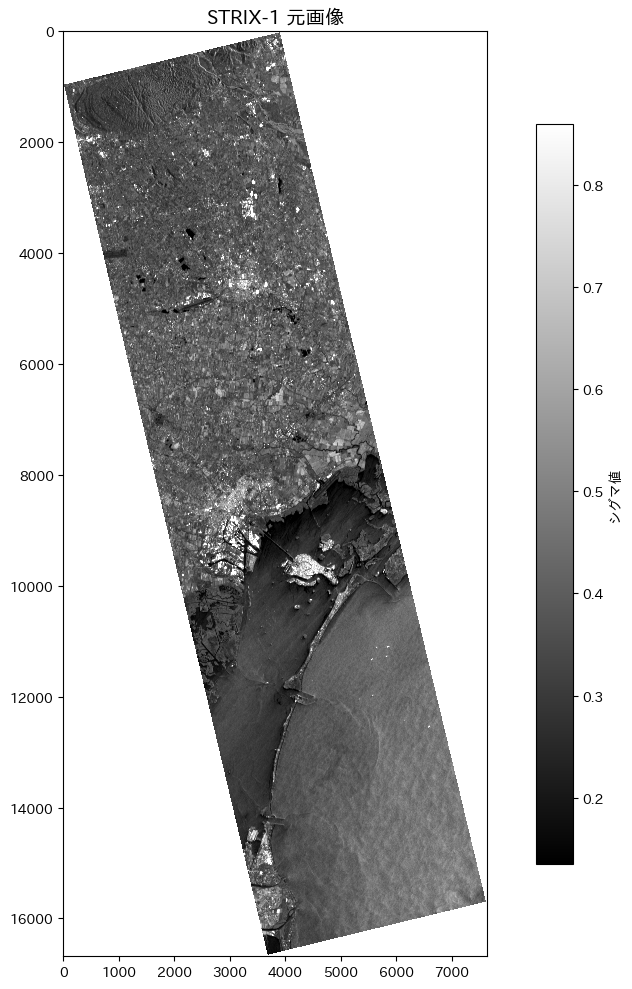

2-98パーセンタイル: 0.1354 - 0.8599


In [4]:
# 可視化用のパーセンタイル値を計算
p2, p98 = np.nanpercentile(sigma_sqrt, [2, 98])

# 元画像を可視化
plt.figure(figsize=(10, 10))
plt.imshow(sigma_sqrt, cmap='gray', vmin=p2, vmax=p98)
plt.title('STRIX-1 元画像', fontsize=14)
plt.colorbar(label='シグマ値', shrink=0.8)
plt.savefig(os.path.join(PATH_OUTPUT, 'figure35.png'), dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

print(f'2-98パーセンタイル: {p2:.4f} - {p98:.4f}')

# 解析領域の切り出し

In [5]:
# 出力ファイルパス
OUTPUT_CLIP = os.path.join(PATH_OUTPUT, 'IMG-VV-STRIX1-20221212T192710Z-SMGRD_clip.tif')

# 画像の読み込みと切り取り
with rio.open(IMG_PATH) as src:
    out_meta = src.meta.copy()
    
    img = src.read(1).astype(np.float32)
    sigma = (img ** 2) / (CALIBRATION_FACTOR ** 2)
    sigma[sigma == 0] = np.nan
    
    # 解析対象領域のウィンドウを設定
    window = rio.windows.Window(
        col_off=CLIP_COL_OFFSET, 
        row_off=CLIP_ROW_OFFSET, 
        width=CLIP_WIDTH, 
        height=CLIP_HEIGHT
    )
    transform = rio.windows.transform(window, src.transform)
    
    # メタデータの更新
    out_meta.update({
        "driver": "GTiff",
        "height": window.height,
        "width": window.width,
        "transform": transform,
        "dtype": 'float32'
    })

    # ウィンドウ領域を切り出し
    img_clip = sigma[
        window.row_off:window.row_off+window.height, 
        window.col_off:window.col_off+window.width
    ]

# 切り出した画像を保存
with rio.open(OUTPUT_CLIP, "w", **out_meta) as dest:
    dest.write(img_clip, 1)

print('=' * 60)
print('解析領域の切り出し完了')
print('=' * 60)
print(f'切り出し領域: {window.width} × {window.height} ピクセル')
print(f'保存先: {OUTPUT_CLIP}')
print('=' * 60)

解析領域の切り出し完了
切り出し領域: 230 × 220 ピクセル
保存先: /work/outputs/water/IMG-VV-STRIX1-20221212T192710Z-SMGRD_clip.tif


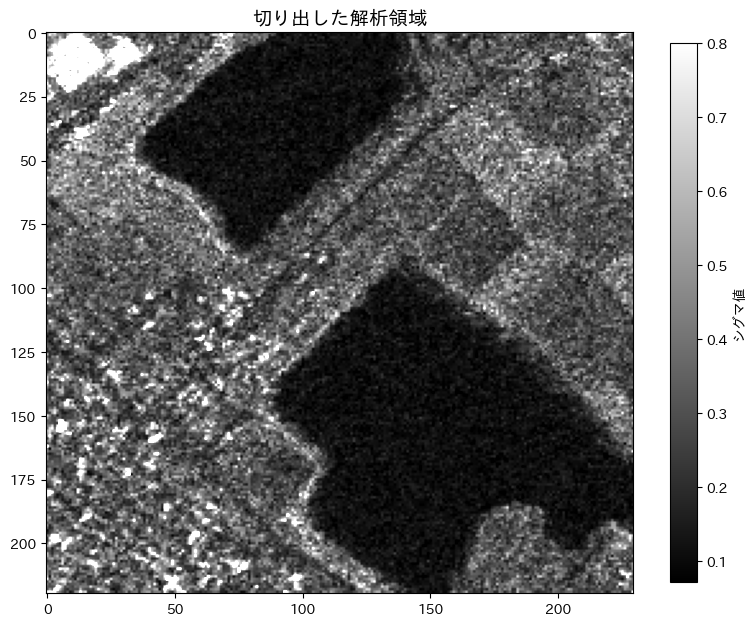

In [13]:
# 切り取った画像の読み込みと可視化
with rio.open(OUTPUT_CLIP) as src:
    sigma_clip = src.read(1).astype(np.float32)
    sigma_clip_sqrt = np.sqrt(sigma_clip)
    
p2, p98 = np.nanpercentile(sigma_clip_sqrt, [2, 98])

plt.figure(figsize=(8, 8))
plt.imshow(sigma_clip_sqrt, cmap='gray', vmin=p2, vmax=p98)
plt.title('切り出した解析領域', fontsize=14)
plt.colorbar(label='シグマ値', shrink=0.7)
plt.savefig(os.path.join(PATH_OUTPUT, 'figure36.png'), dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

# 画像のdB変換とヒストグラム分析

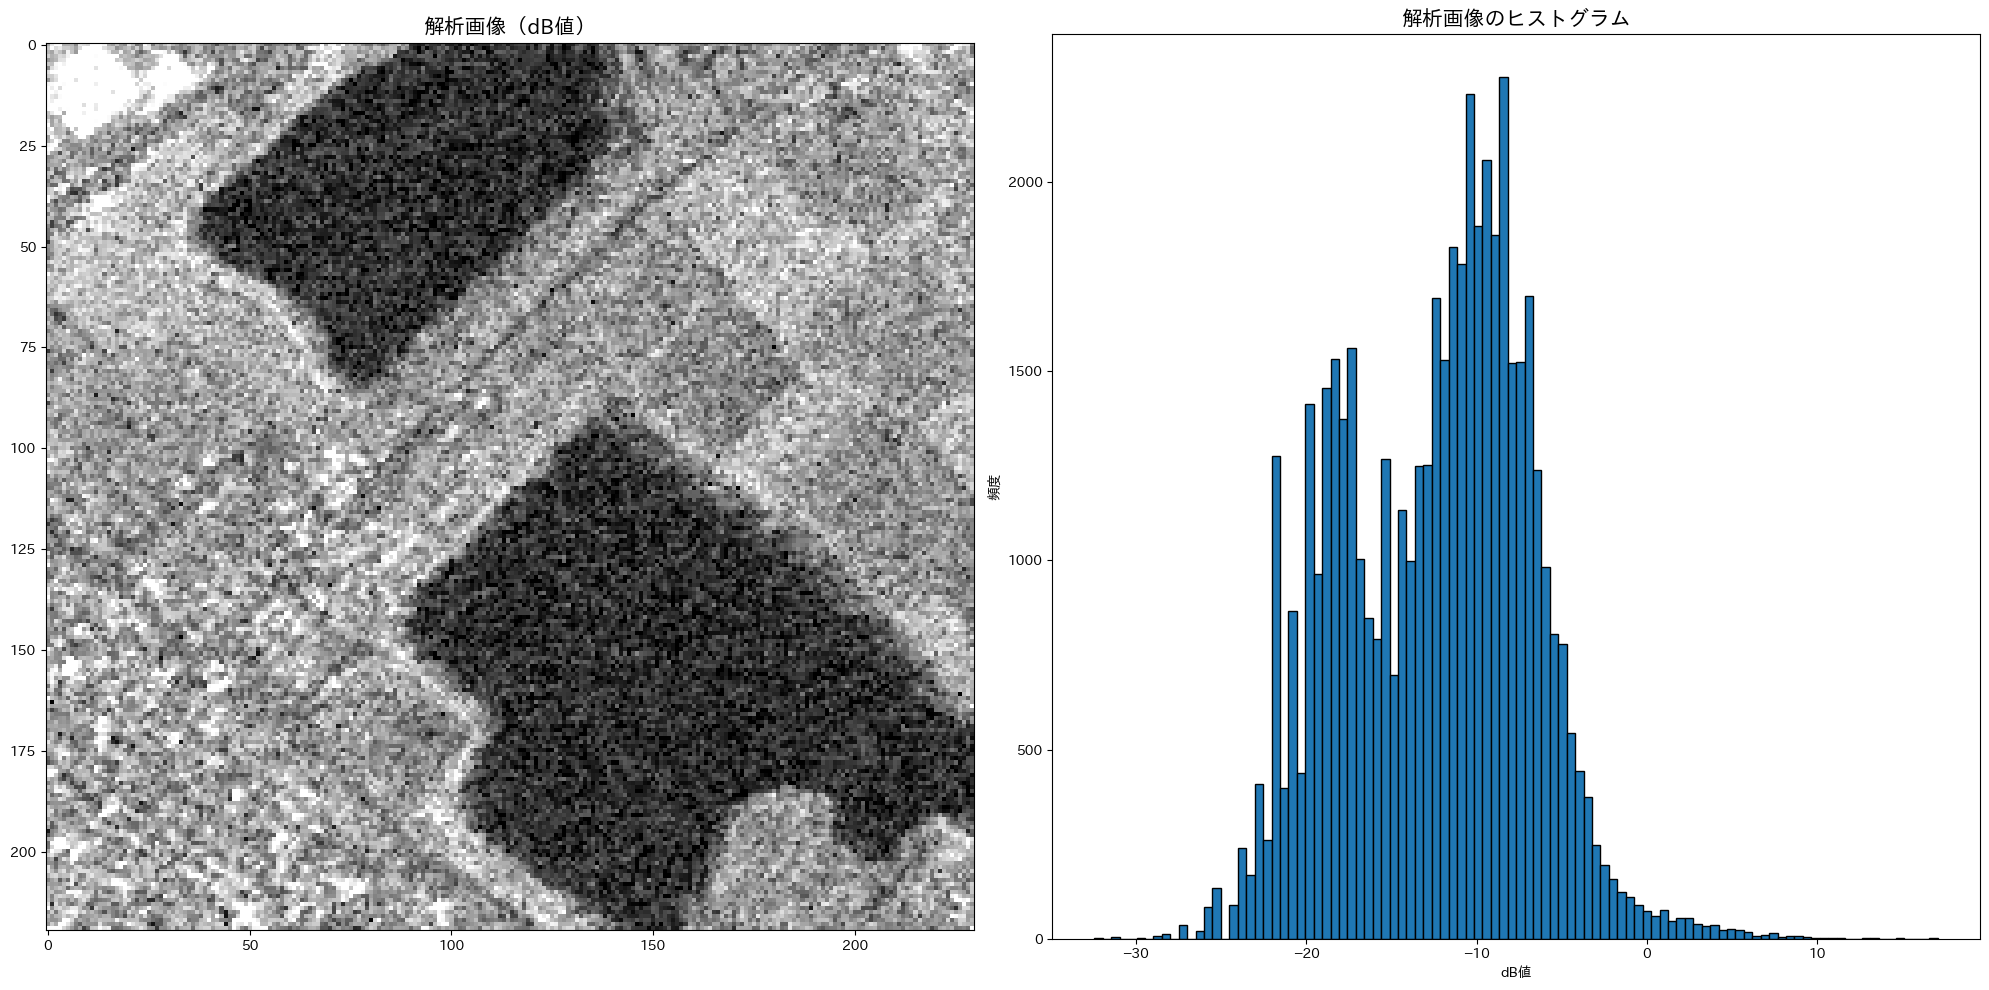

dB変換結果
dB値の範囲: -32.44 - 17.08


In [14]:
# 切り取った画像をdB値に変換
with rio.open(OUTPUT_CLIP) as src:
    img = src.read(1).astype(np.float32)
    img_dB = 10 * np.log10(img)

# 可視化用のパーセンタイル値を計算
p2, p98 = np.nanpercentile(img_dB, [2, 98])

# 解析画像とヒストグラムを表示
plt.figure(figsize=(20, 10))

plt.subplot(1, 2, 1)
plt.imshow(img_dB, cmap='gray', vmin=p2, vmax=p98)
plt.title('解析画像（dB値）', fontsize=15)

plt.subplot(1, 2, 2)
plt.hist(img_dB[~np.isnan(img_dB)].flatten(), bins=100, edgecolor='black')
plt.title('解析画像のヒストグラム', fontsize=15)
plt.xlabel('dB値')
plt.ylabel('頻度')

plt.savefig(os.path.join(PATH_OUTPUT, 'figure37.png'), dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

print('=' * 60)
print('dB変換結果')
print('=' * 60)
print(f'dB値の範囲: {np.nanmin(img_dB):.2f} - {np.nanmax(img_dB):.2f}')
print('=' * 60)

# マルチルック処理

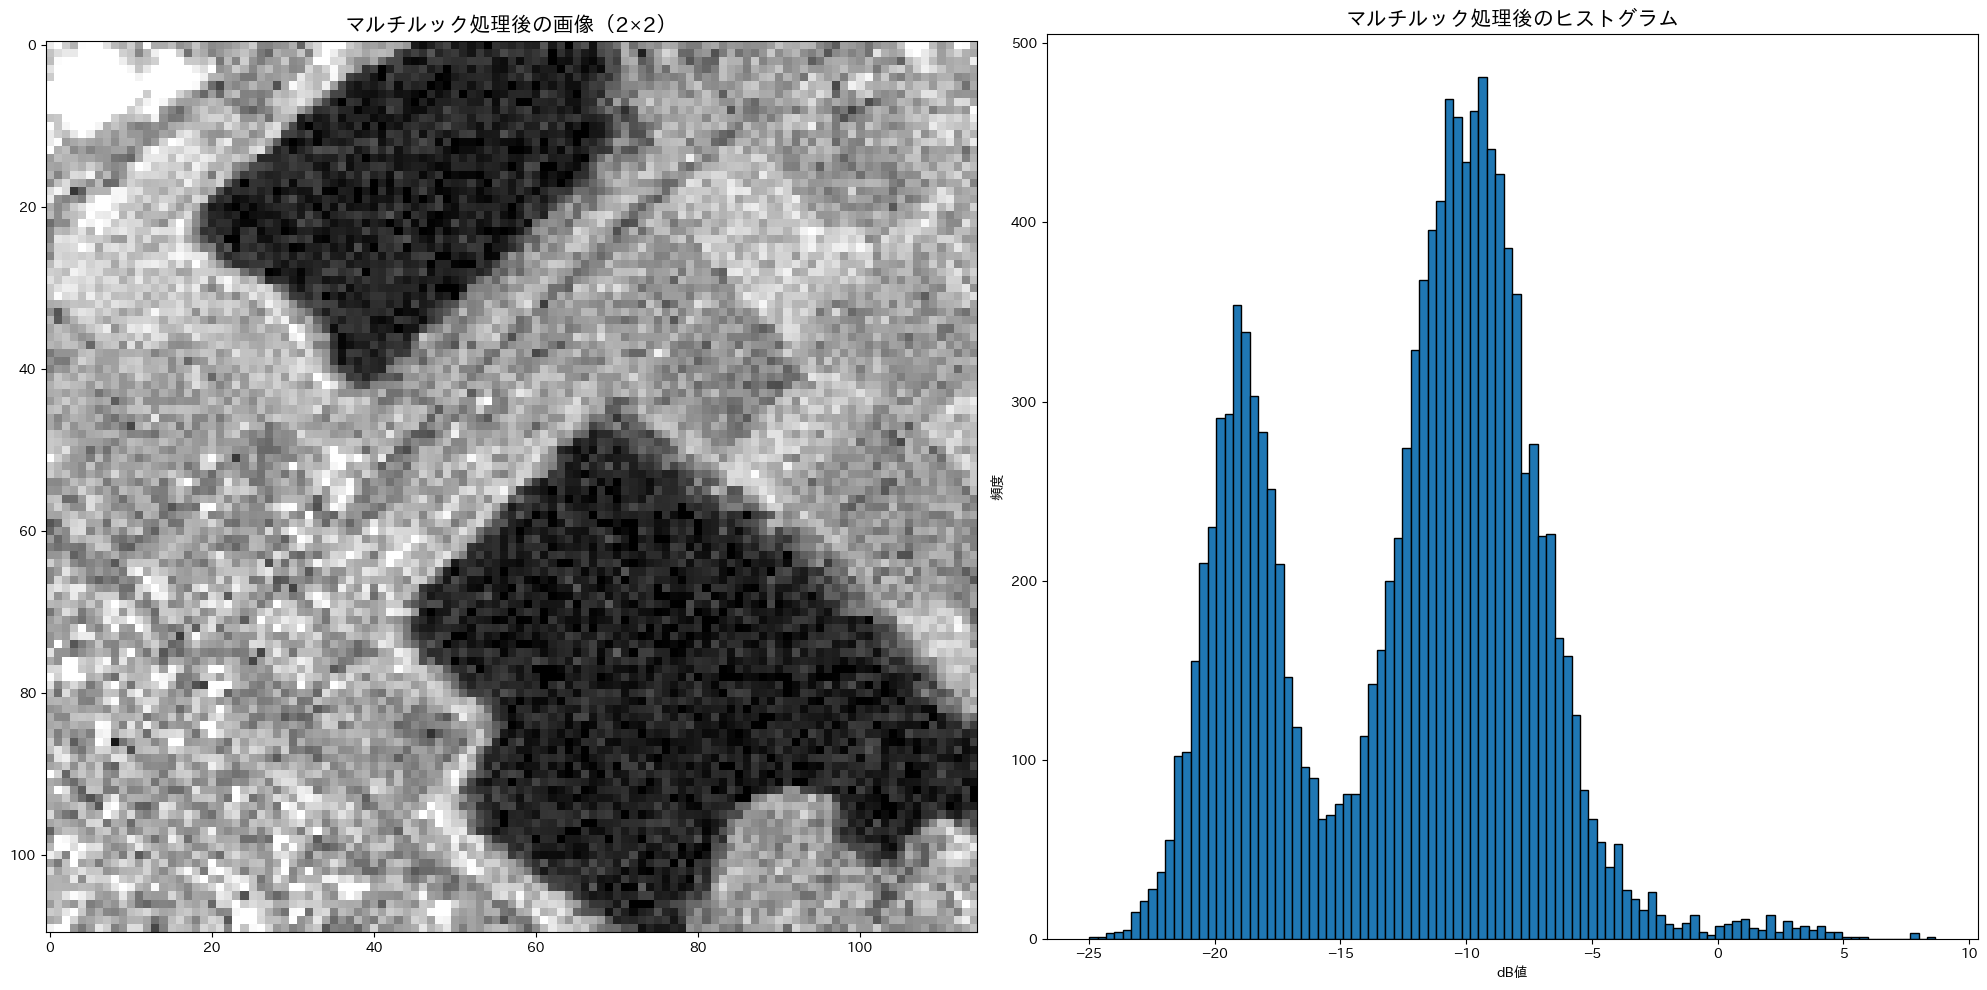

マルチルック処理完了
処理前サイズ: 220 × 230 ピクセル
処理後サイズ: 110 × 115 ピクセル
マルチルックサイズ: 2×2


In [15]:
# マルチルック処理用の画像サイズとピクセル数を設定
reshaped_data = img_dB.reshape(
    (img_dB.shape[0] // MULTILOOK_SIZE, MULTILOOK_SIZE, 
     img_dB.shape[1] // MULTILOOK_SIZE, MULTILOOK_SIZE)
)

# マルチルック処理の実施（2×2の平均化）
multilooked_data = reshaped_data.mean(axis=(1, 3))

# マルチルック処理後の画像とヒストグラムを可視化
p2, p98 = np.nanpercentile(multilooked_data, [2, 98])

plt.figure(figsize=(20, 10))

plt.subplot(1, 2, 1)
plt.imshow(multilooked_data, cmap='gray', vmin=p2, vmax=p98)
plt.title(f'マルチルック処理後の画像（{MULTILOOK_SIZE}×{MULTILOOK_SIZE}）', fontsize=15)

plt.subplot(1, 2, 2)
plt.hist(multilooked_data[~np.isnan(multilooked_data)].flatten(), bins=100, edgecolor='black')
plt.title('マルチルック処理後のヒストグラム', fontsize=15)
plt.xlabel('dB値')
plt.ylabel('頻度')

plt.savefig(os.path.join(PATH_OUTPUT, 'figure38.png'), dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

print('=' * 60)
print('マルチルック処理完了')
print('=' * 60)
print(f'処理前サイズ: {img_dB.shape[0]} × {img_dB.shape[1]} ピクセル')
print(f'処理後サイズ: {multilooked_data.shape[0]} × {multilooked_data.shape[1]} ピクセル')
print(f'マルチルックサイズ: {MULTILOOK_SIZE}×{MULTILOOK_SIZE}')
print('=' * 60)

# 四分木分割による領域タイル化

四分木分割完了
L+タイル数: 182
L+タイルサイズ: 8×8 ピクセル
L-タイルサイズ: 4×4 ピクセル


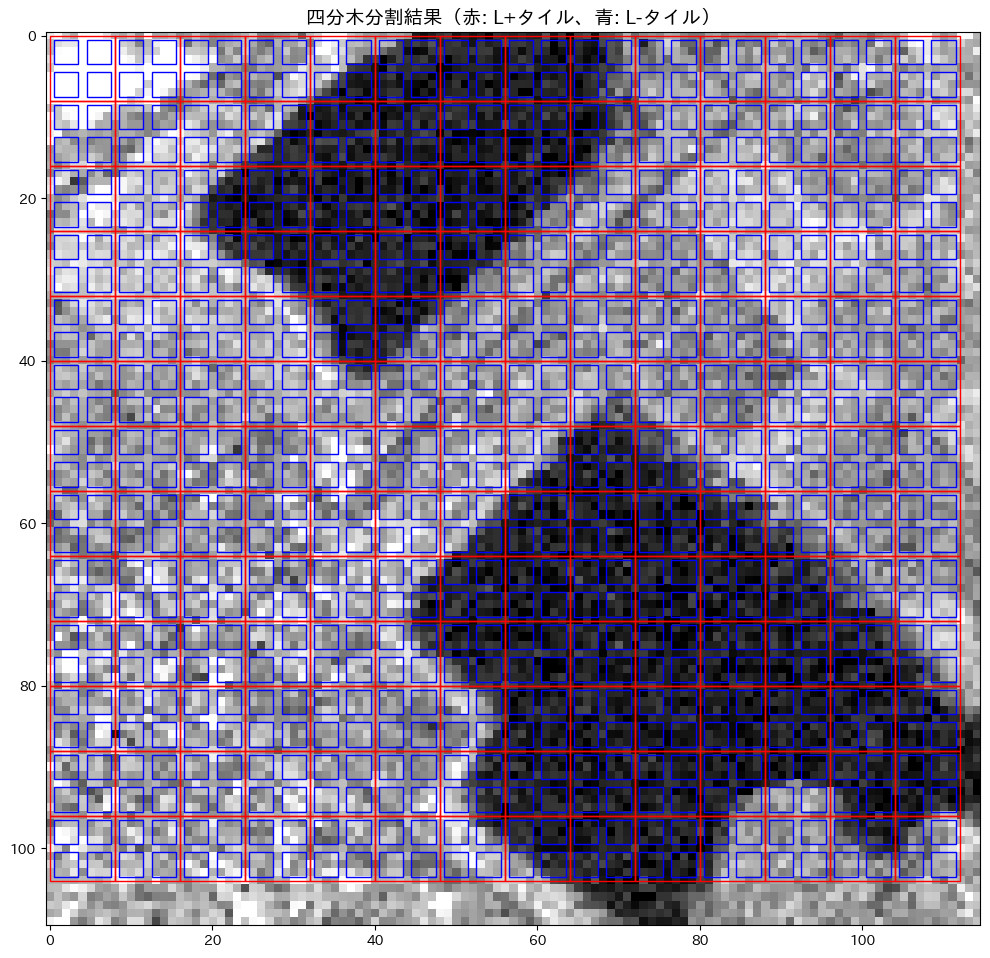

In [9]:
def create_tiles(image, tile_size):
    """
    2段階の四分木分割を実施してタイルを生成する関数
    
    画像を指定されたサイズのタイル（L+）に分割し、さらに各L+タイルを
    4つのサブタイル（L-）に分割します。
    
    Parameters:
    -----------
    image : ndarray
        入力画像（2次元配列）
    tile_size : int
        L+タイルのサイズ（tile_size × tile_size ピクセル）
    
    Returns:
    --------
    l_plus : list of ndarray
        L+タイルのリスト
    l_plus_positions : list of tuple
        L+タイルの位置情報（y_start, y_end, x_start, x_end）
    l_minus : list of list of ndarray
        L-タイルのリスト（各L+タイルに対応する4つのL-タイル）
    l_minus_positions : list of list of tuple
        L-タイルの位置情報
    """
    # 画像のサイズとタイルのサイズから縦横のタイル数を設定
    height, width = image.shape
    n_rows = int(np.ceil(height / tile_size))
    n_cols = int(np.ceil(width / tile_size))

    # L+とL-のタイルを生成
    l_plus = []
    l_plus_positions = []
    l_minus = []
    l_minus_positions = []
    
    for i in range(n_rows):
        for j in range(n_cols):
            y_start = i * tile_size
            y_end = min((i + 1) * tile_size, height)
            x_start = j * tile_size
            x_end = min((j + 1) * tile_size, width)
            l_plus_tile = image[y_start:y_end, x_start:x_end]

            # 正方形のタイルのみ保存
            if l_plus_tile.shape[0] == l_plus_tile.shape[1]: 
                l_plus.append(l_plus_tile)
                l_plus_positions.append((y_start, y_end, x_start, x_end))

                l_minus_tiles = []
                l_minus_tiles_positions = []
                l_plus_height, l_plus_width = l_plus_tile.shape
                half_tile_size = int(np.ceil(tile_size / 2))

                for y in range(0, l_plus_height, half_tile_size):
                    for x in range(0, l_plus_width, half_tile_size):
                        y_end_local = min(y + half_tile_size, l_plus_height)
                        x_end_local = min(x + half_tile_size, l_plus_width)
                        l_minus_tile = l_plus_tile[y:y_end_local, x:x_end_local]
                        l_minus_tiles.append(l_minus_tile)
                        l_minus_tiles_positions.append(
                            (y_start + y, y_start + y_end_local, 
                             x_start + x, x_start + x_end_local)
                        )
                
                l_minus.append(l_minus_tiles)
                l_minus_positions.append(l_minus_tiles_positions)

    return l_plus, l_plus_positions, l_minus, l_minus_positions


def tile_visualization(image, l_plus_positions, l_minus_positions):
    """
    四分木分割の結果を可視化する関数
    
    L+タイルを赤枠、L-タイルを青枠で画像上に表示します。
    
    Parameters:
    -----------
    image : ndarray
        ベース画像
    l_plus_positions : list of tuple
        L+タイルの位置情報
    l_minus_positions : list of list of tuple
        L-タイルの位置情報
    """
    fig, ax = plt.subplots(figsize=(10, 10))

    p2, p98 = np.nanpercentile(image, [2, 98])
    ax.imshow(image, cmap='gray', vmin=p2, vmax=p98)

    # L+のタイル群を可視化
    for i in range(len(l_plus_positions)):
        y_start, y_end, x_start, x_end = l_plus_positions[i]
        rect = plt.Rectangle(
            (x_start, y_start), x_end-x_start, y_end-y_start, 
            edgecolor='red', facecolor='none', linewidth=1
        )
        ax.add_patch(rect)
    
    # L-のタイル群を可視化
    for i in range(len(l_minus_positions)):
        for j in range(len(l_minus_positions[i])):
            y_start, y_end, x_start, x_end = l_minus_positions[i][j]
            rect = plt.Rectangle(
                (x_start+0.5, y_start+0.5), x_end-x_start-1, y_end-y_start-1, 
                edgecolor='blue', facecolor='none', linewidth=1
            )
            ax.add_patch(rect)
    
    ax.set_title('四分木分割結果（赤: L+タイル、青: L-タイル）', fontsize=14)
    plt.savefig(os.path.join(PATH_OUTPUT, 'figure39.png'), dpi=150, bbox_inches='tight')
    plt.tight_layout()
    plt.show()


# 2段階の四分木分割の実行
l_plus, l_plus_positions, l_minus, l_minus_positions = create_tiles(
    multilooked_data, 
    tile_size=TILE_SIZE
)

print('=' * 60)
print('四分木分割完了')
print('=' * 60)
print(f'L+タイル数: {len(l_plus)}')
print(f'L+タイルサイズ: {TILE_SIZE}×{TILE_SIZE} ピクセル')
print(f'L-タイルサイズ: {TILE_SIZE//2}×{TILE_SIZE//2} ピクセル')
print('=' * 60)

# 四分木分割の可視化
tile_visualization(multilooked_data, l_plus_positions, l_minus_positions)

# 変動係数による水域候補領域の抽出

変動係数分析結果
変動係数の範囲: -1.1858 - 9.4792
90パーセンタイル閾値: -0.0164
抽出されたタイル数: 19


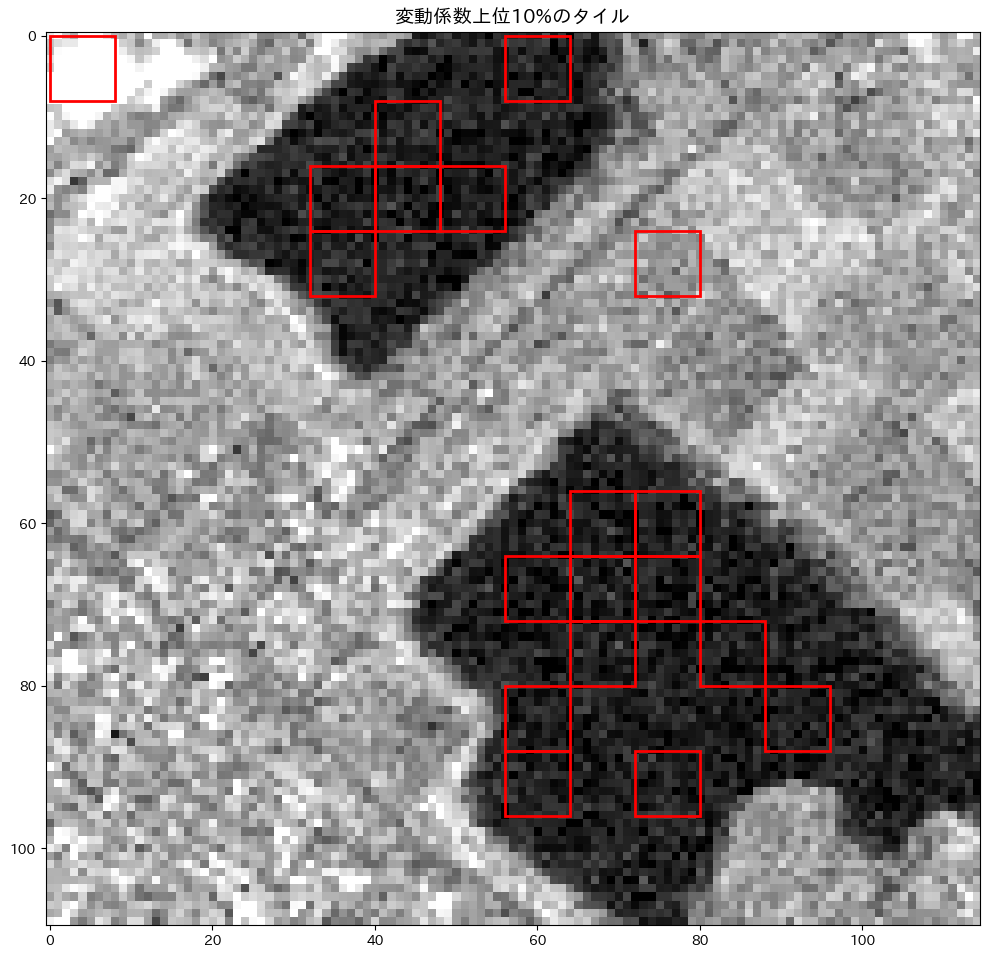

In [10]:
def calculate_coefficient_of_variation(l_plus, l_minus):
    """
    L+タイルとL-タイルの統計情報から変動係数を算出する関数
    
    各L+タイル内のL-タイルの平均値の標準偏差を、L+タイルの平均値で正規化することで
    変動係数を計算します。変動係数が大きいタイルは、水域と非水域の境界を含む可能性が高いです。
    
    Parameters:
    -----------
    l_plus : list of ndarray
        L+タイルのリスト
    l_minus : list of list of ndarray
        L-タイルのリスト
    
    Returns:
    --------
    coefficients_of_variation : list of float
        各L+タイルの変動係数
    """
    coefficients_of_variation = []

    for i, l_plus_tile in enumerate(l_plus):
        l_minus_tiles = l_minus[i]
        l_minus_means = [np.mean(tile) for tile in l_minus_tiles]
        mean_std = np.std(l_minus_means)
        l_plus_mean = np.mean(l_plus_tile)
        coefficient_of_variation = mean_std / l_plus_mean
        coefficients_of_variation.append(coefficient_of_variation)

    return coefficients_of_variation


def extract_top_percentile(coefficients_of_variation, percentile):
    """
    変動係数のリストから指定したパーセンタイルを超えるインデックスと値を抽出する関数
    
    Parameters:
    -----------
    coefficients_of_variation : list of float
        変動係数のリスト
    percentile : float
        抽出する閾値のパーセンタイル（0-100）
    
    Returns:
    --------
    top_coefficients : list of tuple
        (インデックス, 変動係数) のタプルのリスト
    """
    threshold = np.percentile(coefficients_of_variation, percentile)
    
    top_coefficients = []
    for i, cv in enumerate(coefficients_of_variation):
        if cv > threshold:
            top_coefficients.append((i, cv))

    return top_coefficients


def visualize_top_tiles(image, l_plus_positions, top_coefficients):
    """
    変動係数を基に抽出したタイルを可視化する関数
    
    Parameters:
    -----------
    image : ndarray
        ベース画像
    l_plus_positions : list of tuple
        L+タイルの位置情報
    top_coefficients : list of tuple
        上位変動係数のタイル情報
    """
    fig, ax = plt.subplots(figsize=(10, 10))

    p2, p98 = np.nanpercentile(image, [2, 98])
    ax.imshow(image, cmap='gray', vmin=p2, vmax=p98)

    for i, cv in top_coefficients:
        y_start, y_end, x_start, x_end = l_plus_positions[i]
        rect = plt.Rectangle(
            (x_start, y_start), x_end - x_start, y_end - y_start, 
            edgecolor='red', facecolor='none', linewidth=2
        )
        ax.add_patch(rect)
    
    ax.set_title(f'変動係数上位{100-CV_PERCENTILE}%のタイル', fontsize=14)
    plt.savefig(os.path.join(PATH_OUTPUT, 'figure40.png'), dpi=150, bbox_inches='tight')
    plt.tight_layout()
    plt.show()


# 変動係数の算出
coefficients_of_variation = calculate_coefficient_of_variation(l_plus, l_minus)

# 上位パーセンタイルのタイルを抽出
top_coefficients = extract_top_percentile(
    coefficients_of_variation, 
    percentile=CV_PERCENTILE
)

print('=' * 60)
print('変動係数分析結果')
print('=' * 60)
print(f'変動係数の範囲: {np.min(coefficients_of_variation):.4f} - {np.max(coefficients_of_variation):.4f}')
print(f'{CV_PERCENTILE}パーセンタイル閾値: {np.percentile(coefficients_of_variation, CV_PERCENTILE):.4f}')
print(f'抽出されたタイル数: {len(top_coefficients)}')
print('=' * 60)

# 抽出されたタイルの可視化
visualize_top_tiles(multilooked_data, l_plus_positions, top_coefficients)

# 局所閾値の決定と水域抽出

水域候補タイルの抽出結果
候補タイル数: 17
全体L+タイル平均値: -12.5556 dB
候補タイル平均値範囲: -19.7871 - -18.8101 dB


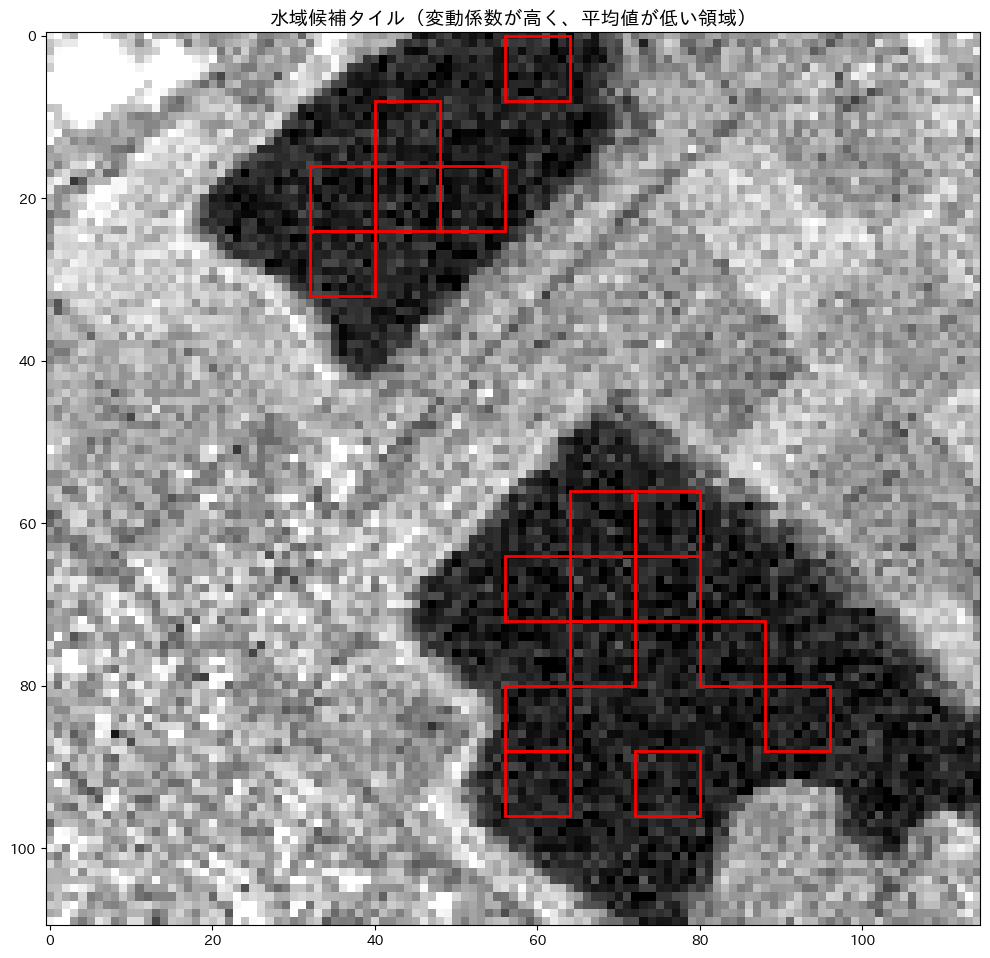

In [11]:
def check_and_return_l_plus_below_average(l_plus, top_coefficients):
    """
    全体のL+タイルの平均値よりも低い平均値を持つL+タイルを抽出する関数
    
    変動係数が高いタイルの中から、さらに平均値が低いタイルを抽出することで、
    水域を含む可能性の高い領域を特定します。
    
    Parameters:
    -----------
    l_plus : list of ndarray
        L+タイルのリスト
    top_coefficients : list of tuple
        上位変動係数のタイル情報
    
    Returns:
    --------
    l_plus_below_average : list of ndarray
        平均値が全体平均より低いL+タイルのリスト
    indices_below_average : list of int
        該当するタイルのインデックスリスト
    """
    all_l_plus_means = [np.mean(tile) for tile in l_plus]
    average_of_all_l_plus = np.mean(all_l_plus_means)

    l_plus_below_average = []
    indices_below_average = []
    for i, _ in top_coefficients:
        top_l_plus_mean = np.mean(l_plus[i])
        if top_l_plus_mean < average_of_all_l_plus:
            l_plus_below_average.append(l_plus[i])
            indices_below_average.append(i)

    return l_plus_below_average, indices_below_average


def visualize_selected_tiles(image, l_plus_positions, indices_below_average):
    """
    選択されたL+タイルを可視化する関数
    
    Parameters:
    -----------
    image : ndarray
        ベース画像
    l_plus_positions : list of tuple
        L+タイルの位置情報
    indices_below_average : list of int
        選択されたタイルのインデックスリスト
    """
    fig, ax = plt.subplots(figsize=(10, 10))

    p2, p98 = np.nanpercentile(image, [2, 98])
    ax.imshow(image, cmap='gray', vmin=p2, vmax=p98)

    for i in indices_below_average:
        y_start, y_end, x_start, x_end = l_plus_positions[i]
        rect = plt.Rectangle(
            (x_start, y_start), x_end - x_start, y_end - y_start, 
            edgecolor='red', facecolor='none', linewidth=2
        )
        ax.add_patch(rect)
    
    ax.set_title('水域候補タイル（変動係数が高く、平均値が低い領域）', fontsize=14)
    plt.savefig(os.path.join(PATH_OUTPUT, 'figure41.png'), dpi=150, bbox_inches='tight')
    plt.tight_layout()
    plt.show()


# 平均値が全体平均より低いタイルを抽出
l_plus_below_average, indices_below_average = check_and_return_l_plus_below_average(
    l_plus, 
    top_coefficients
)

print('=' * 60)
print('水域候補タイルの抽出結果')
print('=' * 60)
print(f'候補タイル数: {len(indices_below_average)}')
all_l_plus_means = [np.mean(tile) for tile in l_plus]
average_of_all_l_plus = np.mean(all_l_plus_means)
print(f'全体L+タイル平均値: {average_of_all_l_plus:.4f} dB')
if len(l_plus_below_average) > 0:
    candidate_means = [np.mean(tile) for tile in l_plus_below_average]
    print(f'候補タイル平均値範囲: {np.min(candidate_means):.4f} - {np.max(candidate_means):.4f} dB')
print('=' * 60)

# 選択されたタイルの可視化
visualize_selected_tiles(multilooked_data, l_plus_positions, indices_below_average)

# 2値化結果の可視化と保存

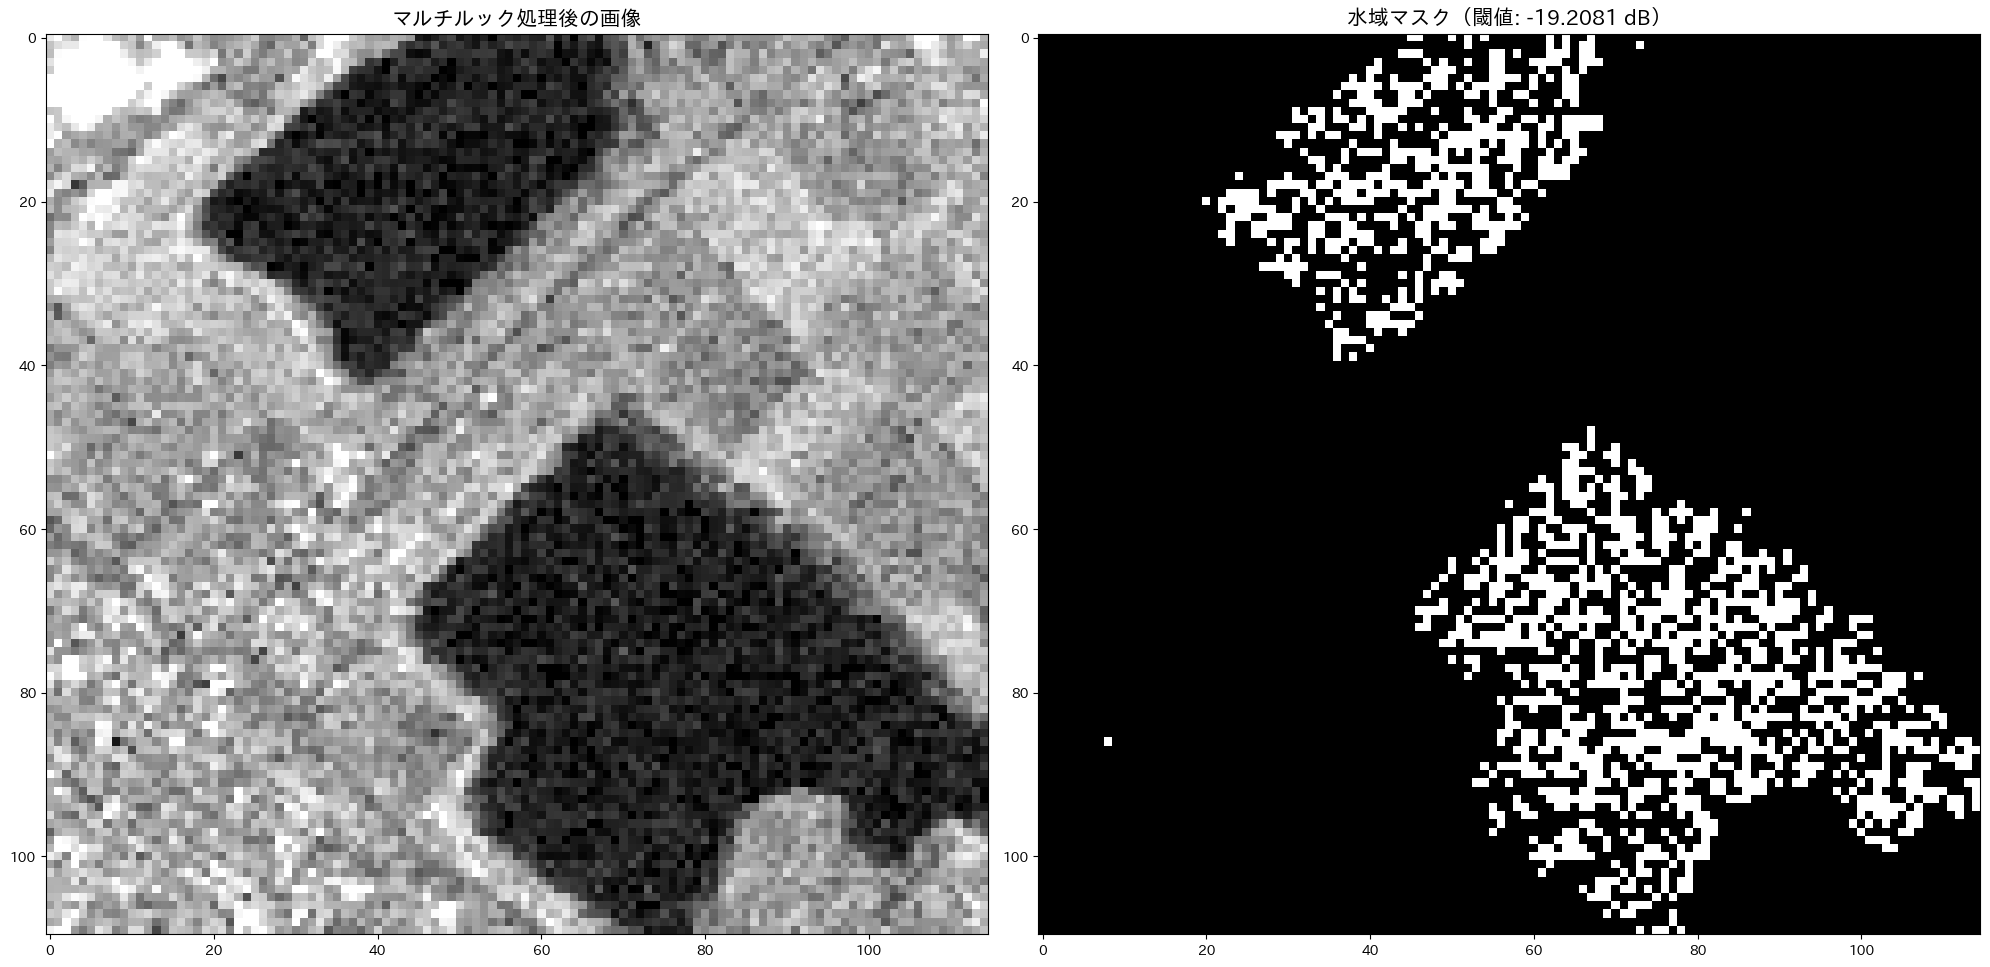

局所閾値法による水域抽出完了
決定された閾値: -19.2081 dB
水域ピクセル数: 1612
非水域ピクセル数: 11038
水域面積率: 12.74%


In [16]:
# 閾値の算出（水域候補タイルの平均値を閾値として使用）
threshold = np.mean(l_plus_below_average)

# 閾値を用いて2値化（閾値より小さい値を水域とする）
water_mask = np.where(multilooked_data < threshold, 1, 0)

# 2値化結果を可視化
p2, p98 = np.nanpercentile(multilooked_data, [2, 98])

plt.figure(figsize=(20, 10))

plt.subplot(1, 2, 1)
plt.imshow(multilooked_data, cmap='gray', vmin=p2, vmax=p98)
plt.title('マルチルック処理後の画像', fontsize=15)

plt.subplot(1, 2, 2)
plt.imshow(water_mask, cmap='gray')
plt.title(f'水域マスク（閾値: {threshold:.4f} dB）', fontsize=15)

plt.savefig(os.path.join(PATH_OUTPUT, 'figure42.png'), dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

print('=' * 60)
print('局所閾値法による水域抽出完了')
print('=' * 60)
print(f'決定された閾値: {threshold:.4f} dB')
print(f'水域ピクセル数: {np.sum(water_mask)}')
print(f'非水域ピクセル数: {np.sum(water_mask == 0)}')
print(f'水域面積率: {np.sum(water_mask) / water_mask.size * 100:.2f}%')
print('=' * 60)